# =============================================================================
# SVR WIND SPEED FORECASTING WITH HYPERPARAMETER OPTIMIZATION
# =============================================================================
# This script implements Support Vector Regression (SVR) for wind speed
# forecasting using lag features, with three hyperparameter tuning methods:
# Original (manual), Grid Search, Randomized Search, and Optuna.
# =============================================================================

#

─────────────────────────────────────────────────────────────────────────────
# SECTION 1: PACKAGE INSTALLATION
# ─────────────────────────────────────────────────────────────────────────────


In [12]:

!pip install optuna
!pip install statsmodels
!pip install tabulate



#──────────────────────────────────────────────────────────────────────────
# SECTION 2: IMPORT LIBRARIES
#───────────────────────────────────────────────────────────────────────────


In [13]:


# Standard libraries
import sys       # System-specific parameters and functions
import os        # Miscellaneous operating system interfaces
import random    # Random number generation
import warnings  # Warning control
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd   # Data manipulation and analysis
import numpy as np    # Numerical operations

# Visualization
import matplotlib.pyplot as plt                        # Plotting library
import seaborn as sns                                  # Statistical data visualization
import plotly.graph_objects as go                      # Interactive plotting
from matplotlib.colors import ListedColormap           # Colormap utilities

# Model Helpers
from sklearn.preprocessing import (
    OneHotEncoder, LabelEncoder, MinMaxScaler          # Preprocessing tools
)
from sklearn import model_selection, metrics, preprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit                                    # Time-aware cross-validation
)
from sklearn.svm import SVR                            # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.tree import DecisionTreeClassifier        # Decision tree classifier

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import (
    pointbiserialr, chi2_contingency, spearmanr,
    entropy, uniform, randint
)
from statsmodels.graphics.gofplots import qqplot       # Q-Q plot
from collections import Counter                        # Container datatypes

# Tabulate
from tabulate import tabulate                          # Pretty-print tabular data

# Optuna for Bayesian optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # Suppress Optuna verbose output



# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────


In [14]:

# Dataset source (Google Sheets exported as CSV):
# https://docs.google.com/spreadsheets/d/1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC

sheet_id  = "1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC"
sheet_name = "Sheet1"
csv_url   = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

# Read the Google Sheet as CSV
df = pd.read_csv(csv_url)

# Backup original DataFrame before any modifications
df_backup = df.copy()

# Set Date as the index
df = df.set_index('Date')

# Drop calendar columns (YEAR, MO, DY) — not needed as model features
df = df.drop(columns=["YEAR", "MO", "DY"])

# Keep only the target variable: Wind Speed at 10 metres (WS10M)
df = df[["WS10M"]]

print("Dataset loaded. Shape:", df.shape)
print(df.head())

Dataset loaded. Shape: (4017, 1)
                     WS10M
Date                      
2013-01-01 00:00:00   3.99
2013-01-02 00:00:00   4.25
2013-01-03 00:00:00   4.75
2013-01-04 00:00:00   5.74
2013-01-05 00:00:00   5.79


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: FEATURE ENGINEERING — LAG FEATURES
# ──

In [15]:
# Define the number of lag terms for autoregressive features
num_lags = 3

# Create lag features for WS10M
lagged_df = df.copy()
for lag in range(1, num_lags + 1):
    lagged_features = df.shift(lag).add_suffix(f'_lag{lag}')
    lagged_df = pd.concat([lagged_df, lagged_features], axis=1)

# Drop rows with NaN values introduced by lagging
lagged_df = lagged_df.dropna()

print("\nLagged DataFrame (first 5 rows):")
print(lagged_df.head())

df = lagged_df


Lagged DataFrame (first 5 rows):
                     WS10M  WS10M_lag1  WS10M_lag2  WS10M_lag3
Date                                                          
2013-01-04 00:00:00   5.74        4.75        4.25        3.99
2013-01-05 00:00:00   5.79        5.74        4.75        4.25
2013-01-06 00:00:00   4.52        5.79        5.74        4.75
2013-01-07 00:00:00   4.66        4.52        5.79        5.74
2013-01-08 00:00:00   3.61        4.66        4.52        5.79


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: DEFINE FEATURES AND TARGET
# ─────────────────────────────────────────────────────────────────────────────


In [16]:

X = df.drop(columns=['WS10M'])    # Features: lagged wind speed variables
y = df['WS10M']                   # Target:   current wind speed

print("\nFeature columns:", X.columns.tolist())




Feature columns: ['WS10M_lag1', 'WS10M_lag2', 'WS10M_lag3']


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: TRAIN-TEST SPLIT (chronological, no shuffling)
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: For time series forecasting, data must be split chronologically
# to avoid data leakage (future data must never influence past predictions).

train_size  = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


Shapes:
X_train shape: (3211, 3)
y_train shape: (3211,)
X_test shape: (803, 3)
y_test shape: (803,)


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: PREPROCESSING — MIN-MAX SCALING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: The scaler is fit ONLY on the training set and then applied to the
# test set. Fitting on the full dataset before splitting would cause data
# leakage, as the test set statistics would influence the training transform.

# Scale all feature columns (lag variables); the target y is not scaled
cols_to_scale = X.columns.tolist()

scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])  # Fit + transform on train
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])       # Transform only on test

print("\nX_train after scaling (first 5 rows):")
print(X_train.head())


X_train after scaling (first 5 rows):
                     WS10M_lag1  WS10M_lag2  WS10M_lag3
Date                                                   
2013-01-04 00:00:00    0.439080    0.381609    0.351724
2013-01-05 00:00:00    0.552874    0.439080    0.381609
2013-01-06 00:00:00    0.558621    0.552874    0.439080
2013-01-07 00:00:00    0.412644    0.558621    0.552874
2013-01-08 00:00:00    0.428736    0.412644    0.558621


In [19]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: HELPER FUNCTION — PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def calculate_metrics(y_true, y_pred, dataset_name, model_name=""):
    """
    Calculate and print regression performance metrics.

    Parameters:
        y_true       : array-like, actual values
        y_pred       : array-like, predicted values
        dataset_name : str, label for the dataset (e.g., 'Train', 'Test')
        model_name   : str, optional label for the model/kernel

    Returns:
        mse, rmse, mae, mape, r2
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    label = f"{dataset_name} Metrics" + (f" [{model_name}]" if model_name else "")
    print(f"\n{label}:")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.4f}%")
    print(f"  R²   : {r2:.4f}")

    return mse, rmse, mae, mape, r2


Original Model — Cross-Validation MAE (Mean): 0.6142

Train Metrics [Original SVR]:
  MSE  : 0.6260
  RMSE : 0.7912
  MAE  : 0.6056
  MAPE : 17.5945%
  R²   : 0.7516

Test Metrics [Original SVR]:
  MSE  : 0.7586
  RMSE : 0.8710
  MAE  : 0.6680
  MAPE : 18.8642%
  R²   : 0.6854


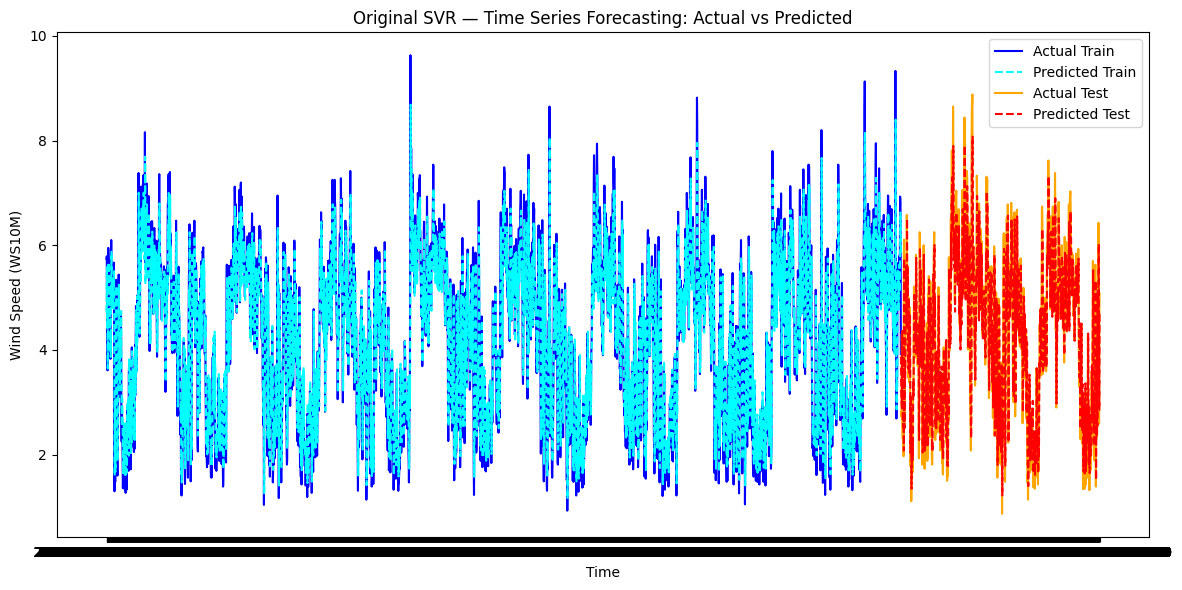

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: ORIGINAL SVR MODEL (Manual Hyperparameters)
# ─────────────────────────────────────────────────────────────────────────────

# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

# Define Time Series Split for cross-validation
tscv_original = TimeSeriesSplit(n_splits=10)

# Define SVR model with manually set hyperparameters
# gamma = 1 / (2 * p^2) with p = 5
svr_original = SVR(kernel='rbf', C=500, gamma=1 / (2 * (5 ** 2)))

# Perform Time Series Cross-Validation on training set
cv_scores_original = []
for train_idx, val_idx in tscv_original.split(X_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    svr_original.fit(X_train_fold, y_train_fold)
    y_val_pred_original = svr_original.predict(X_val_fold)

    mae_fold = mean_absolute_error(y_val_fold, y_val_pred_original)
    cv_scores_original.append(mae_fold)

print(f"\nOriginal Model — Cross-Validation MAE (Mean): {np.mean(cv_scores_original):.4f}")

# Train final model on the full training set
svr_original.fit(X_train, y_train)

# Predictions
y_train_pred_original = svr_original.predict(X_train)
y_test_pred_original  = svr_original.predict(X_test)

# Evaluate and store metrics
ORIGINAL_TRAIN_MSE, ORIGINAL_TRAIN_RMSE, ORIGINAL_TRAIN_MAE, ORIGINAL_TRAIN_MAPE, ORIGINAL_TRAIN_R2 = \
    calculate_metrics(y_train, y_train_pred_original, "Train", "Original SVR")

ORIGINAL_TEST_MSE, ORIGINAL_TEST_RMSE, ORIGINAL_TEST_MAE, ORIGINAL_TEST_MAPE, ORIGINAL_TEST_R2 = \
    calculate_metrics(y_test, y_test_pred_original, "Test", "Original SVR")

# Plot: Actual vs Predicted (Train and Test)
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train,              label='Actual Train',    color='blue')
plt.plot(y_train.index, y_train_pred_original, label='Predicted Train', color='cyan',   linestyle='dashed')
plt.plot(y_test.index,  y_test,               label='Actual Test',     color='orange')
plt.plot(y_test.index,  y_test_pred_original,  label='Predicted Test',  color='red',    linestyle='dashed')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Wind Speed (WS10M)")
plt.title("Original SVR — Time Series Forecasting: Actual vs Predicted")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Grid Search — Best Parameters: {'C': 10, 'degree': 2, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}

Train Metrics [Grid Search (linear)]:
  MSE  : 0.6284
  RMSE : 0.7927
  MAE  : 0.6070
  MAPE : 17.6355%
  R²   : 0.7506

Test Metrics [Grid Search (linear)]:
  MSE  : 0.7577
  RMSE : 0.8705
  MAE  : 0.6676
  MAPE : 18.8374%
  R²   : 0.6858


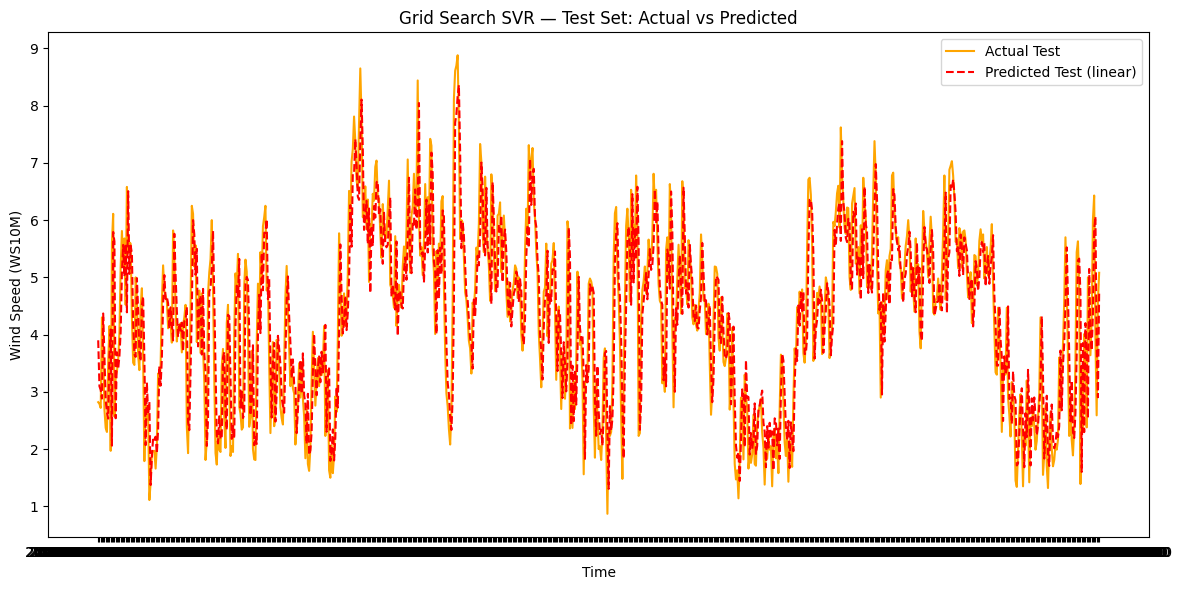

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: GRID SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(seed)
random.seed(seed)

# Define Time Series Split for Grid Search cross-validation
tscv_grid = TimeSeriesSplit(n_splits=5)

# Define the hyperparameter search grid
param_grid = {
    'kernel':  ['linear', 'poly'],
    'C':       [1, 10, 100],
    'epsilon': [0.01, 0.1],
    'degree':  [2, 3],
    'gamma':   ['scale', 'auto']
}

# Run GridSearchCV with time series cross-validation
svr_grid = SVR()
grid_search = GridSearchCV(
    estimator  = svr_grid,
    param_grid = param_grid,
    cv         = tscv_grid,
    scoring    = 'neg_mean_absolute_error',    # Minimise MAE
    n_jobs     = -1,
    verbose    = 2
)
grid_search.fit(X_train, y_train)

print(f"\nGrid Search — Best Parameters: {grid_search.best_params_}")

# Retrieve best model and generate predictions
best_svr_grid = grid_search.best_estimator_
y_train_pred_grid = best_svr_grid.predict(X_train)
y_test_pred_grid  = best_svr_grid.predict(X_test)

# Evaluate and store metrics
best_kernel_grid = grid_search.best_params_['kernel']

GRID_TRAIN_MSE, GRID_TRAIN_RMSE, GRID_TRAIN_MAE, GRID_TRAIN_MAPE, GRID_TRAIN_R2 = \
    calculate_metrics(y_train, y_train_pred_grid, "Train", f"Grid Search ({best_kernel_grid})")

GRID_TEST_MSE, GRID_TEST_RMSE, GRID_TEST_MAE, GRID_TEST_MAPE, GRID_TEST_R2 = \
    calculate_metrics(y_test, y_test_pred_grid, "Test", f"Grid Search ({best_kernel_grid})")

# Plot: Actual vs Predicted (Test Set)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test,             label='Actual Test',  color='orange')
plt.plot(y_test.index, y_test_pred_grid,   label=f'Predicted Test ({best_kernel_grid})',
         color='red', linestyle='dashed')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Wind Speed (WS10M)")
plt.title("Grid Search SVR — Test Set: Actual vs Predicted")
plt.tight_layout()
plt.show()

Fitting 10 folds for each of 100 candidates, totalling 1000 fits

Randomized Search — Best Parameters: {'C': np.float64(9.449399034383031), 'degree': 2, 'epsilon': np.float64(0.04693220645902588), 'gamma': 'auto', 'kernel': 'rbf'}

Train Metrics [Randomized Search (rbf)]:
  MSE  : 0.6212
  RMSE : 0.7881
  MAE  : 0.6025
  MAPE : 17.4069%
  R²   : 0.7535

Test Metrics [Randomized Search (rbf)]:
  MSE  : 0.7658
  RMSE : 0.8751
  MAE  : 0.6703
  MAPE : 18.7928%
  R²   : 0.6824


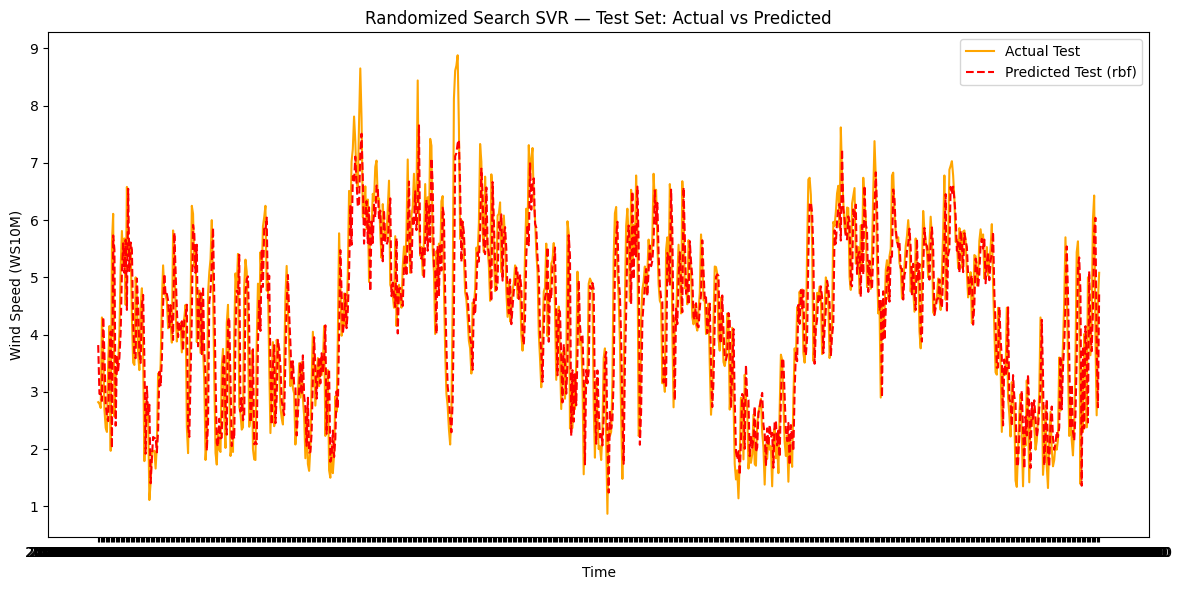

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: RANDOMIZED SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(seed)
random.seed(seed)

# Define Time Series Split for Randomized Search cross-validation
tscv_random = TimeSeriesSplit(n_splits=10)

# Define the hyperparameter distribution for random sampling
param_dist = {
    'kernel':  ['linear', 'poly', 'rbf'],
    'C':       uniform(loc=1,    scale=99),     # Continuous uniform [1, 100]
    'epsilon': uniform(loc=0.01, scale=0.19),   # Continuous uniform [0.01, 0.2]
    'degree':  randint(2, 6),                   # Integers in [2, 5]
    'gamma':   ['scale', 'auto', 1e-3, 1e-2]
}

# Run RandomizedSearchCV with time series cross-validation
svr_random = SVR()
random_search = RandomizedSearchCV(
    estimator            = svr_random,
    param_distributions  = param_dist,
    n_iter               = 100,
    cv                   = tscv_random,
    scoring              = 'neg_mean_absolute_error',
    n_jobs               = -1,
    verbose              = 2,
    random_state         = seed
)
random_search.fit(X_train, y_train)

print(f"\nRandomized Search — Best Parameters: {random_search.best_params_}")

# Retrieve best model and generate predictions
best_svr_random = random_search.best_estimator_
y_train_pred_random = best_svr_random.predict(X_train)
y_test_pred_random  = best_svr_random.predict(X_test)

# Evaluate and store metrics
best_kernel_random = random_search.best_params_['kernel']

RANDOM_TRAIN_MSE, RANDOM_TRAIN_RMSE, RANDOM_TRAIN_MAE, RANDOM_TRAIN_MAPE, RANDOM_TRAIN_R2 = \
    calculate_metrics(y_train, y_train_pred_random, "Train", f"Randomized Search ({best_kernel_random})")

RANDOM_TEST_MSE, RANDOM_TEST_RMSE, RANDOM_TEST_MAE, RANDOM_TEST_MAPE, RANDOM_TEST_R2 = \
    calculate_metrics(y_test, y_test_pred_random, "Test", f"Randomized Search ({best_kernel_random})")

# Plot: Actual vs Predicted (Test Set)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test,              label='Actual Test',  color='orange')
plt.plot(y_test.index, y_test_pred_random,  label=f'Predicted Test ({best_kernel_random})',
         color='red', linestyle='dashed')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Wind Speed (WS10M)")
plt.title("Randomized Search SVR — Test Set: Actual vs Predicted")
plt.tight_layout()
plt.show()

In [23]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: OPTUNA BAYESIAN HYPERPARAMETER OPTIMIZATION
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(seed)
random.seed(seed)

# Define the objective function for Optuna minimization
def objective(trial):
    """
    Optuna objective function: trains an SVR with trial hyperparameters
    and returns the mean MSE across Time Series CV folds.
    """
    kernel  = trial.suggest_categorical('kernel',  ['linear', 'poly', 'rbf'])
    # NOTE: suggest_float with log=True replaces deprecated suggest_loguniform
    C       = trial.suggest_float('C',       1,    100,  log=True)
    # NOTE: suggest_float replaces deprecated suggest_uniform
    epsilon = trial.suggest_float('epsilon', 0.01, 0.2)
    degree  = trial.suggest_int(  'degree',  2,    5)
    gamma   = trial.suggest_categorical('gamma', ['scale', 'auto', 1e-3, 1e-2])

    tscv_optuna = TimeSeriesSplit(n_splits=5)
    fold_mse = []

    for train_index, val_index in tscv_optuna.split(X_train):
        X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

        svr_trial = SVR(
            kernel  = kernel,
            C       = C,
            epsilon = epsilon,
            degree  = degree,
            gamma   = gamma
        )
        svr_trial.fit(X_train_cv, y_train_cv)
        y_val_pred_cv = svr_trial.predict(X_val_cv)
        fold_mse.append(mean_squared_error(y_val_cv, y_val_pred_cv))

    return np.mean(fold_mse)

# Create Optuna study (minimise MSE) with fixed seed for reproducibility
study = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=seed)
)
study.optimize(objective, n_trials=50)

best_params_optuna = study.best_params
print(f"\nOptuna — Best Parameters: {best_params_optuna}")

# Train best Optuna model on the full training set
best_svr_optuna = SVR(**best_params_optuna)
best_svr_optuna.fit(X_train, y_train)

# Predictions
y_train_pred_optuna = best_svr_optuna.predict(X_train)
y_test_pred_optuna  = best_svr_optuna.predict(X_test)

# Evaluate and store metrics
OPTUNA_TRAIN_MSE, OPTUNA_TRAIN_RMSE, OPTUNA_TRAIN_MAE, OPTUNA_TRAIN_MAPE, OPTUNA_TRAIN_R2 = \
    calculate_metrics(y_train, y_train_pred_optuna, "Train", "Optuna SVR")

OPTUNA_TEST_MSE, OPTUNA_TEST_RMSE, OPTUNA_TEST_MAE, OPTUNA_TEST_MAPE, OPTUNA_TEST_R2 = \
    calculate_metrics(y_test, y_test_pred_optuna, "Test", "Optuna SVR")

# Display Optuna trial results table using Plotly
optuna_results   = pd.DataFrame(study.trials_dataframe())
optuna_table_df  = optuna_results[[
    'number', 'params_kernel', 'params_C', 'params_epsilon',
    'params_degree', 'params_gamma', 'value'
]].copy()
optuna_table_df.columns = ['Trial', 'Kernel', 'C', 'Epsilon', 'Degree', 'Gamma', 'Test MSE']

fig_table_optuna = go.Figure(go.Table(
    header=dict(values=optuna_table_df.columns.tolist()),
    cells=dict(values=[optuna_table_df[col].tolist() for col in optuna_table_df.columns])
))
fig_table_optuna.update_layout(
    title    = "Optuna Results — Hyperparameter Tuning (SVR)",
    template = "plotly_white",
    height   = 500
)
fig_table_optuna.show()

# Interactive time series plot: Actual vs Predicted (Train and Test)
fig_optuna = go.Figure()

fig_optuna.add_trace(go.Scatter(
    x=y_train.index, y=y_train,
    mode='lines', name='Actual Train',
    line=dict(color='blue')
))
fig_optuna.add_trace(go.Scatter(
    x=y_train.index, y=y_train_pred_optuna,
    mode='lines', name='Predicted Train',
    line=dict(color='cyan', dash='dash')
))
fig_optuna.add_trace(go.Scatter(
    x=y_test.index, y=y_test,
    mode='lines', name='Actual Test',
    line=dict(color='red')
))
fig_optuna.add_trace(go.Scatter(
    x=y_test.index, y=y_test_pred_optuna,
    mode='lines', name='Predicted Test',
    line=dict(color='orange', dash='dash')
))

fig_optuna.update_layout(
    title      = "Optuna SVR — Time Series Plot: Actual vs Predicted",
    xaxis_title = "Time",
    yaxis_title = "Wind Speed (WS10M)",
    template   = "plotly_white",
    legend     = dict(x=0, y=1)
)
fig_optuna.show()


Optuna — Best Parameters: {'kernel': 'rbf', 'C': 8.59094366512061, 'epsilon': 0.02791632909203344, 'degree': 2, 'gamma': 'auto'}

Train Metrics [Optuna SVR]:
  MSE  : 0.6212
  RMSE : 0.7881
  MAE  : 0.6025
  MAPE : 17.4224%
  R²   : 0.7535

Test Metrics [Optuna SVR]:
  MSE  : 0.7648
  RMSE : 0.8745
  MAE  : 0.6698
  MAPE : 18.7910%
  R²   : 0.6829


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: COMPARATIVE RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────

# Compile all evaluation metrics into a single comparison DataFrame
metrics_df = pd.DataFrame({
    "Method":     ["Original Model", "Grid Search", "Randomized Search", "Optuna"],
    "Train MSE":  [ORIGINAL_TRAIN_MSE,  GRID_TRAIN_MSE,  RANDOM_TRAIN_MSE,  OPTUNA_TRAIN_MSE],
    "Test MSE":   [ORIGINAL_TEST_MSE,   GRID_TEST_MSE,   RANDOM_TEST_MSE,   OPTUNA_TEST_MSE],
    "Train RMSE": [ORIGINAL_TRAIN_RMSE, GRID_TRAIN_RMSE, RANDOM_TRAIN_RMSE, OPTUNA_TRAIN_RMSE],
    "Test RMSE":  [ORIGINAL_TEST_RMSE,  GRID_TEST_RMSE,  RANDOM_TEST_RMSE,  OPTUNA_TEST_RMSE],
    "Train MAE":  [ORIGINAL_TRAIN_MAE,  GRID_TRAIN_MAE,  RANDOM_TRAIN_MAE,  OPTUNA_TRAIN_MAE],
    "Test MAE":   [ORIGINAL_TEST_MAE,   GRID_TEST_MAE,   RANDOM_TEST_MAE,   OPTUNA_TEST_MAE],
    "Train MAPE": [ORIGINAL_TRAIN_MAPE, GRID_TRAIN_MAPE, RANDOM_TRAIN_MAPE, OPTUNA_TRAIN_MAPE],
    "Test MAPE":  [ORIGINAL_TEST_MAPE,  GRID_TEST_MAPE,  RANDOM_TEST_MAPE,  OPTUNA_TEST_MAPE],
    "Train R²":   [ORIGINAL_TRAIN_R2,   GRID_TRAIN_R2,   RANDOM_TRAIN_R2,   OPTUNA_TRAIN_R2],
    "Test R²":    [ORIGINAL_TEST_R2,    GRID_TEST_R2,    RANDOM_TEST_R2,    OPTUNA_TEST_R2],
})

print("\nModel Comparison — Evaluation Metrics:")
print(metrics_df.to_string(index=False))

# Save the metrics DataFrame to CSV
metrics_df.to_csv("variableSet_1_SVR.csv", index=False)
print("\nMetrics saved to variableSet_1_SVR.csv")


Model Comparison — Evaluation Metrics:
           Method  Train MSE  Test MSE  Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE  Test MAPE  Train R²  Test R²
   Original Model   0.625991  0.758605    0.791196   0.870979   0.605569  0.667951   17.594545  18.864239  0.751590 0.685414
      Grid Search   0.628396  0.757697    0.792714   0.870458   0.606991  0.667647   17.635530  18.837424  0.750635 0.685791
Randomized Search   0.621151  0.765806    0.788131   0.875103   0.602510  0.670310   17.406856  18.792785  0.753510 0.682429
           Optuna   0.621154  0.764751    0.788133   0.874501   0.602545  0.669802   17.422429  18.791032  0.753509 0.682866

Metrics saved to variableSet_1_SVR.csv
